# Exercice 4 - Régression sur le dataset fourni

Le dataset est stocké dans `project/data/regression/` sous forme de quatre fichiers `.npy` :
`X_train`, `X_test` (200 lignes, 200 colonnes chacun) et `y_train`, `y_test` (200 valeurs chacun).

On a donc autant de variables que d'observations (d = n = 200). Dans cette situation, une régression
linéaire ordinaire interpole exactement les données d'entraînement et généralise très mal : c'est ce
qui motive la comparaison avec des méthodes régularisées. On compare trois estimateurs (régression
linéaire, Ridge, Lasso) et on cherche un R² supérieur à 0.88 sur le jeu de test, ce dernier ne devant
jamais servir pendant l'entraînement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy').ravel()
y_test = np.load('y_test.npy').ravel()

## Préparation des données

On standardise les variables explicatives, ce qui est important pour Ridge et Lasso dont la pénalité
dépend de l'échelle des coefficients. Les moyennes et écarts-types sont calculés uniquement sur le jeu d'entraînement, puis appliqués au jeu de test : ainsi aucune information du test ne participe à
l'entraînement. On ne touche pas à `y`, dont l'échelle n'a pas besoin d'être modifiée pour ces modèles.

In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

## Entraînement des modèles

On compare trois estimateurs : régression linéaire, Ridge et Lasso. Pour Ridge et Lasso, le coefficient
de régularisation est choisi par validation croisée à 5 plis sur le seul jeu d'entraînement, en explorant
une grille de valeurs. Le choix de cet hyperparamètre par validation croisée fait donc partie de
l'entraînement ; le jeu de test n'intervient à aucun moment.

In [4]:
lr = LinearRegression()
rd = RidgeCV(alphas=np.logspace(-6, 6, 100), cv=5)
ls = LassoCV(cv=5, max_iter=10000)

lr.fit(X_train, y_train)
rd.fit(X_train, y_train)
ls.fit(X_train, y_train)

print(f"alpha choisi (Ridge) : {rd.alpha_:.4f}")
print(f"alpha choisi (Lasso) : {ls.alpha_:.4f}")
print(f"coefficients non nuls retenus par Lasso : {np.sum(ls.coef_ != 0)} / {X_train.shape[1]}")

alpha choisi (Ridge) : 10.7227
alpha choisi (Lasso) : 0.0208
coefficients non nuls retenus par Lasso : 38 / 200


## Évaluation

On reporte pour chaque modèle le R² sur l'entraînement et sur le test, ainsi que la MSE de test.
L'écart entre le R² d'entraînement et le R² de test mesure le sur-apprentissage.

In [5]:
for name, model in [("Régression linéaire", lr), ("Ridge", rd), ("Lasso", ls)]:
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)
    mse_test = mean_squared_error(y_test, pred_test)
    print(f"{name:20s} | R2 train = {r2_train:7.4f} | R2 test = {r2_test:7.4f} | MSE test = {mse_test:.4f}")

Régression linéaire  | R2 train =  1.0000 | R2 test = -9.9240 | MSE test = 8.0421
Ridge                | R2 train =  0.9891 | R2 test =  0.7141 | MSE test = 0.2105
Lasso                | R2 train =  0.9593 | R2 test =  0.9231 | MSE test = 0.0566


## Visualisation

Pour chaque modèle, on trace les valeurs prédites en fonction des valeurs réelles sur le jeu de test.
Plus les points sont proches de la diagonale rouge, meilleure est la prédiction.

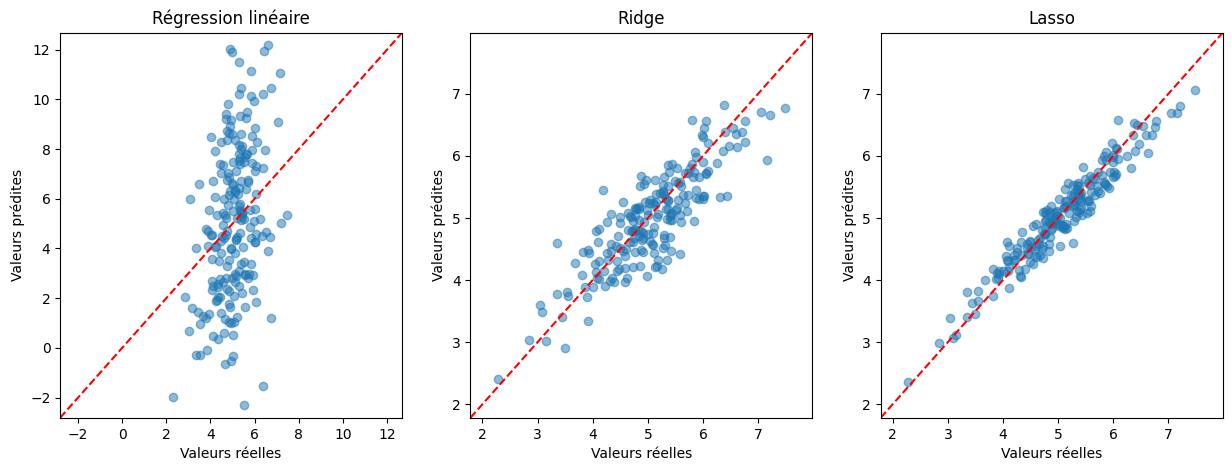

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
models = [("Régression linéaire", lr), ("Ridge", rd), ("Lasso", ls)]

for i, (title, model) in enumerate(models):
    pred = model.predict(X_test)
    lims = [min(y_test.min(), pred.min()) - 0.5, max(y_test.max(), pred.max()) + 0.5]
    axs[i].scatter(y_test, pred, alpha=0.5)
    axs[i].plot(lims, lims, 'r--')
    axs[i].set_xlabel("Valeurs réelles")
    axs[i].set_ylabel("Valeurs prédites")
    axs[i].set_title(title)
    axs[i].set_xlim(lims)
    axs[i].set_ylim(lims)

plt.show()

## Discussion

- **Régression linéaire** : avec d = n = 200, le modèle atteint un R² d'entraînement de 1 mais un R²
  de test fortement négatif. C'est le cas typique de sur-apprentissage : sans contrainte, les 200
  coefficients s'ajustent exactement au bruit d'entraînement.
- **Ridge** : la régularisation rétablit une généralisation correcte (R² de test nettement positif),
  mais conserve les 200 variables, ce qui limite la performance ici.
- **Lasso** : c'est le meilleur modèle. En annulant la plupart des coefficients, il ne retient qu'une
  petite partie des variables et atteint un R² de test d'environ 0.92, proche du R² du prédicteur de
  Bayes annoncé (0.92) et bien au-dessus de l'objectif de 0.88. Cela suggère que le vrai modèle est
  parcimonieux : seules quelques variables sur les 200 sont réellement utiles.
- **Optimisation** : `RidgeCV` et `LassoCV` choisissent leur coefficient de régularisation par validation croisée à 5 plis sur le train ; Ridge admet une solution en forme close, tandis que Lasso est résolu par descente de coordonnées, bien adaptée aux solutions parcimonieuses.

## Conclusion

L'objectif (R² de test > 0.88) est atteint par le Lasso. La comparaison montre que,
dans un régime où le nombre de variables égale le nombre d'observations, la régularisation est
indispensable, et qu'une régularisation parcimonieuse (Lasso) est ici la plus adaptée à la structure
des données.